The randomly chosen particle is in position (3, 22) with a spin of -1.0.
The normalized average magnetic moment is 0.007023359999999999


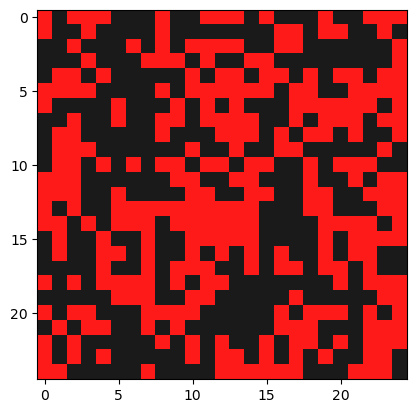

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = 25
y = 25
N=10000
T=10

Paccept = 0
spin_total = 0
lattice = (np.zeros((x,y))+1)

for i in range(0,N):
    adjacent_sum = 0
    random_x = np.random.randint(0,high=x)
    random_y = np.random.randint(0,high=y)
    random_keepTest = np.random.random()
    
    if random_y-1 >= 0:
        adjacent_sum += lattice[random_x,random_y]*lattice[random_x,random_y-1]
    if random_x-1 >= 0:
        adjacent_sum += lattice[random_x,random_y]*lattice[random_x-1,random_y]
    if random_y+1 < y:
        adjacent_sum += lattice[random_x,random_y]*lattice[random_x,random_y+1]
    if random_x+1 < x:
        adjacent_sum += lattice[random_x,random_y]*lattice[random_x+1,random_y]
        
    dE = 2*adjacent_sum
    
    if dE <= 0:
        Paccept = 1
    if dE > 0:
        Paccept = np.exp(-dE/T)
    if random_keepTest < Paccept:
        lattice[random_x,random_y] *= (-1)
        
    if i >= 3*N/4:
        spin_total += np.sum(lattice)

spin_avg = spin_total/(N/4)
spin_norm = (spin_avg)/(x*y)

plt.imshow(lattice,cmap='flag_r',alpha=0.90)

print(
    f'The randomly chosen particle is in position {(random_x,random_y)} with a spin of {lattice[random_x,random_y]}.'
)

print(f'The normalized average magnetic moment is {spin_norm}')

The normalized average magnetic moment is 0.57901952


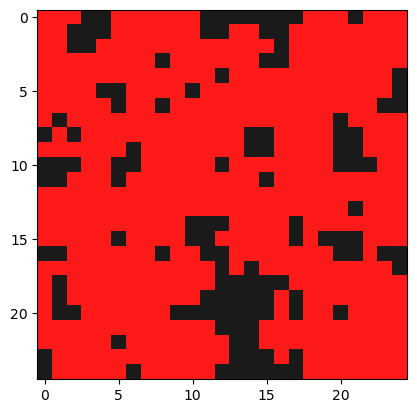

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def lattice(x,y,N,T):
    
    Paccept = 0
    spin_total = 0
    lattice = (np.zeros((x,y))+1)
    
    for i in range(0,N):
        adjacent_sum = 0
        random_x = np.random.randint(0,high=x)
        random_y = np.random.randint(0,high=y)
        random_keepTest = np.random.random()

        if random_y-1 >= 0:
            adjacent_sum += lattice[random_x,random_y]*lattice[random_x,random_y-1]
        if random_x-1 >= 0:
            adjacent_sum += lattice[random_x,random_y]*lattice[random_x-1,random_y]
        if random_y+1 < y:
            adjacent_sum += lattice[random_x,random_y]*lattice[random_x,random_y+1]
        if random_x+1 < x:
            adjacent_sum += lattice[random_x,random_y]*lattice[random_x+1,random_y]

        dE = 2*adjacent_sum

        if dE <= 0:
            Paccept = 1
        if dE > 0:
            Paccept = np.exp(-dE/T)
        if random_keepTest < Paccept:
            lattice[random_x,random_y] *= (-1)

        if i >= 3*N/4:
            spin_total += np.sum(lattice)

    spin_avg = spin_total/(N/4)
    magnetization = (spin_avg)/(x*y)

    return lattice,magnetization

img, magnetization = lattice(25,25,10000,2.5);

plt.imshow(img,cmap='flag_r',alpha=0.90)
print(f'The normalized average magnetic moment is {magnetization}')

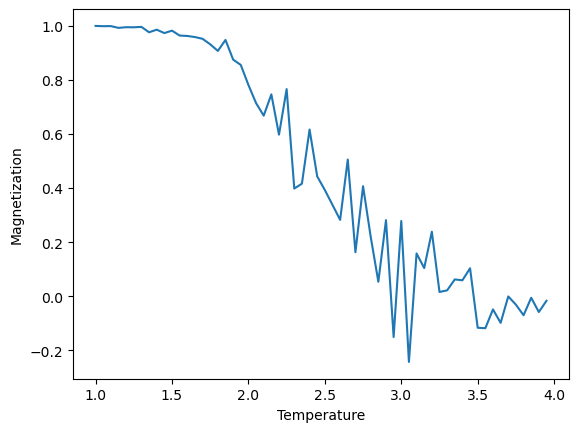

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def lattice(x,y,N,T):
    
    Paccept = 0
    spin_total = 0
    lattice = (np.zeros((x,y))+1)
    
    for i in range(0,N):
        adjacent_sum = 0
        random_x = np.random.randint(0,high=x)
        random_y = np.random.randint(0,high=y)
        random_keepTest = np.random.random()

        if random_y-1 >= 0:
            adjacent_sum += lattice[random_x,random_y]*lattice[random_x,random_y-1]
        if random_x-1 >= 0:
            adjacent_sum += lattice[random_x,random_y]*lattice[random_x-1,random_y]
        if random_y+1 < y:
            adjacent_sum += lattice[random_x,random_y]*lattice[random_x,random_y+1]
        if random_x+1 < x:
            adjacent_sum += lattice[random_x,random_y]*lattice[random_x+1,random_y]

        dE = 2*adjacent_sum

        if dE <= 0:
            Paccept = 1
        if dE > 0:
            Paccept = np.exp(-dE/T)
        if random_keepTest < Paccept:
            lattice[random_x,random_y] *= (-1)

        if i >= 3*N/4:
            spin_total += np.sum(lattice)

    spin_avg = spin_total/(N/4)
    magnetization = (spin_avg)/(x*y)

    return magnetization

T_arr = np.arange(1,4,0.05)
trials = T_arr.size
magnet_arr = np.zeros(trials)

for i in range(trials):
    magnet_arr[i] = lattice(20,20,10000,T_arr[i]);

plt.plot(T_arr,magnet_arr);
plt.xlabel('Temperature');
plt.ylabel('Magnetization');